In [1]:
%load_ext autoreload
%autoreload 2
import pandas as pd
import numpy as np
from collections import defaultdict, deque
from multiprocessing import Manager
from scipy.optimize import linear_sum_assignment
from tqdm.contrib.concurrent import process_map
import networkx as nx
import random
import heapq
import json
from copy import deepcopy
from utils import lineage_name_mapping, load_json, bidict
from zss import simple_distance, Node
from matplotlib import pyplot as plt
from typing import List, Tuple, Dict, Any
from functools import partial
from itertools import combinations

from pareto_core import LineageOptimization, LineageTree

In [2]:
lineage_data = load_json('./data/cell_lineage.json')
lineage_exp_df = pd.read_csv("data/protein/aggregated_all/s3.csv", index_col=0)
lineage_exp_df = lineage_exp_df.fillna(0)
tracking_df_all = pd.read_csv("./data/embryo2/tracks.txt", sep="\t")
tracking_time_cutoff = 242
tracking_scale = 0.1625
tracking_df = tracking_df_all.loc[tracking_df_all["t"] <= tracking_time_cutoff]
untracked_nodes = ["P0", "AB", "P1"]
first_internal_layer = ["ABa", "ABp", "EMS", "P2"]

In [3]:
cell_names = tracking_df["name"].unique()
lineage_xyz_df = pd.DataFrame(columns=["x", "y", "z"])
for name in cell_names:
    time_points = tracking_df.loc[tracking_df['name'] == name]["t"].values
    if len(time_points) == 1 and time_points[0] == tracking_time_cutoff:
        continue
    last_xyz_coordinates = tracking_df.loc[tracking_df['name'] == name][["x", "y", "z"]].values[-1]
    # appending last_xyz_coordinates to lineage_xyz_df as a new row with cell name as index
    lineage_xyz_df.loc[name] = last_xyz_coordinates * tracking_scale

In [4]:
common_lineages = lineage_xyz_df.index.intersection(lineage_exp_df.index)
for name in untracked_nodes:
    lineage_xyz_df.loc[name] = np.repeat(np.nan, 3)
    lineage_exp_df.loc[name] = np.repeat(np.nan, lineage_exp_df.shape[1])
common_lineages = untracked_nodes + common_lineages.tolist()

In [5]:
lineage_tree = LineageTree()
# add first three nodes: ["AB", "P0", "P1"]
lineage_tree.add_node(0, -1)
lineage_tree.root = 0
lineage_tree.add_node(1, 0)
lineage_tree.add_node(2, 0)
bfs_queue = deque()
bfs_queue.append((lineage_data, -1))
while bfs_queue:
    node, parent_idx = bfs_queue.popleft()
    curr_name = lineage_name_mapping(node['did'])
    if curr_name not in common_lineages:
        continue
    curr_idx = common_lineages.index(curr_name)
    if curr_idx >= 3:
        parent_idx = lineage_tree.reverse_lineage_id_mapping[parent_idx]
        lineage_tree.add_node(curr_idx, parent_idx)
    children = node.get('children', [])
    for child_node in children:
        bfs_queue.append((child_node, curr_idx))

print("first layer of tracked nodes:", lineage_tree.children_list[1]+lineage_tree.children_list[2])

first layer of tracked nodes: [3, 4, 5, 6]


In [6]:
lineage_xyz_mat = lineage_xyz_df.loc[common_lineages].values
lineage_exp_mat = lineage_exp_df.loc[common_lineages].values

In [7]:
# check cell division optimality for each internal node
bfs_queue = deque()
for top_node in lineage_tree.children_list[1]+lineage_tree.children_list[2]:
    bfs_queue.append((top_node, 2))

division_optimality_measure = []
while bfs_queue:
    node, depth = bfs_queue.popleft()
    children = lineage_tree.children_list[node]
    for child in children:
        bfs_queue.append((child, depth+1))
    if len(children) == 2:
        left, right = children
        xyz_mid = (lineage_xyz_mat[left] + lineage_xyz_mat[right]) / 2
        exp_mid = (lineage_exp_mat[left] + lineage_exp_mat[right]) / 2
        xyz_dist = np.linalg.norm(lineage_xyz_mat[node] - xyz_mid)
        exp_dist = np.linalg.norm(lineage_exp_mat[node] - exp_mid)
        xyz_children_dist = np.linalg.norm(lineage_xyz_mat[left] - lineage_xyz_mat[right])
        exp_children_dist = np.linalg.norm(lineage_exp_mat[left] - lineage_exp_mat[right])
        division_optimality_measure.append((xyz_dist/xyz_children_dist, exp_dist/exp_children_dist, depth))



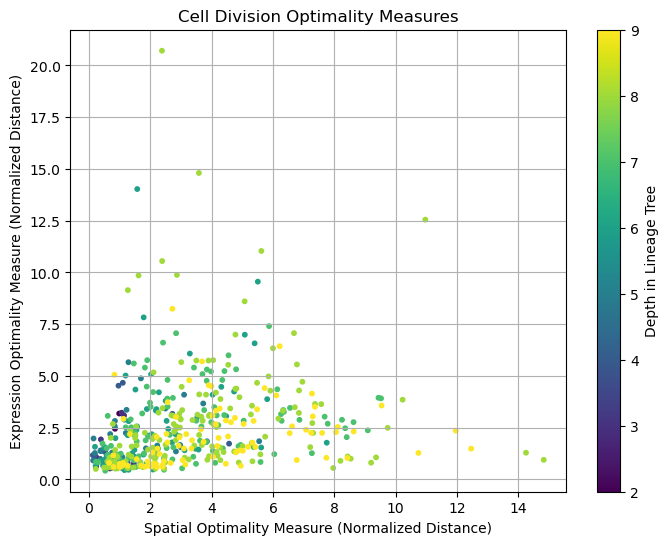

In [11]:
# plot division optimality measure, 
# with x axis as spatial optimality measure, y axis as expression optimality measure, color as depth
division_optimality_measure = np.array(division_optimality_measure)
plt.figure(figsize=(8, 6))
sc = plt.scatter(division_optimality_measure[:, 0], division_optimality_measure[:, 1], c=division_optimality_measure[:, 2], cmap='viridis', s=10)
plt.colorbar(sc, label='Depth in Lineage Tree')
plt.xlabel('Spatial Optimality Measure (Normalized Distance)')
plt.ylabel('Expression Optimality Measure (Normalized Distance)')
plt.title('Cell Division Optimality Measures')
plt.grid(True)
plt.show()

In [8]:
first_layer = [(3,2), (4,2), (5,2), (6,2)]

opt = LineageOptimization(
    lineage_xyz_mat, 
    lineage_exp_mat, 
    lineage_tree,
    first_internal_layer=first_layer,
    lineage_names=common_lineages)

4294.751424520442 106445.0505457176 940


In [49]:
pareto_mst_list = opt.mst_test_runner()

Computing mst test:   0%|          | 0/1001 [00:00<?, ?it/s]

In [12]:
def depth_cutoff_func(depth):
    if depth <= 9:
        return 1
    else:
        return float('inf')

In [ ]:
pareto_list_by_layer = opt.bottom_up_by_layer_runner()
pareto_list_top_down_rebuild = opt.top_down_rebuild_runner()

Computing pareto costs:   0%|          | 0/1001 [00:00<?, ?it/s]

In [11]:
pareto_list_top_down_rebuild_linear_depth_weight = opt.top_down_rebuild_runner(depth_weight_type='linear')
pareto_list_top_down_rebuild_quadratic_depth_weight = opt.top_down_rebuild_runner(depth_weight_type='quadratic')

Computing pareto costs:   0%|          | 0/1001 [00:00<?, ?it/s]

Computing pareto costs:   0%|          | 0/1001 [00:00<?, ?it/s]

In [13]:
pareto_list_top_down_rebuild_depth_cutoff = opt.top_down_rebuild_runner(depth_weight_type=depth_cutoff_func)

Computing pareto costs:   0%|          | 0/1001 [00:00<?, ?it/s]

In [14]:

pareto_list_top_down_rebuild_cubic_depth_weight = opt.top_down_rebuild_runner(depth_weight_type="cubic")

Computing pareto costs:   0%|          | 0/1001 [00:00<?, ?it/s]

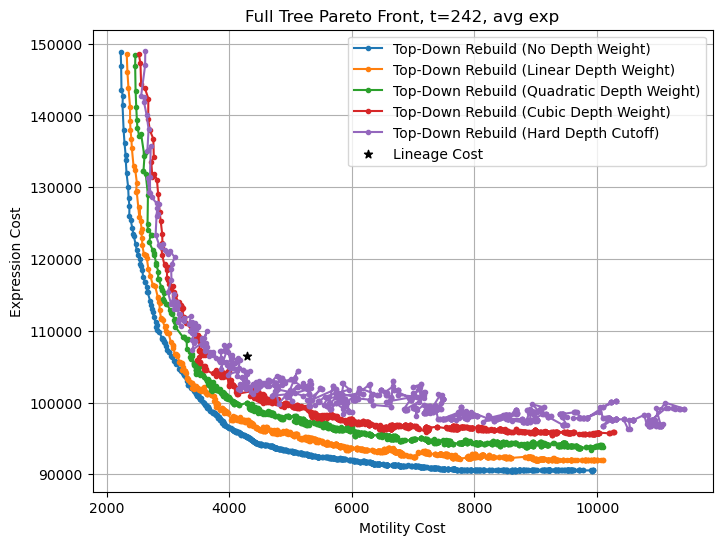

In [18]:
pareto_xyz_cost_list_by_layer = [cost[0] for cost in pareto_list_by_layer]
pareto_exp_cost_list_by_layer = [cost[1] for cost in pareto_list_by_layer]
pareto_xyz_cost_list_top_down_rebuild = [cost[0] for cost in pareto_list_top_down_rebuild]
pareto_exp_cost_list_top_down_rebuild = [cost[1] for cost in pareto_list_top_down_rebuild]
pareto_xyz_cost_list_top_down_rebuild_linear_depth_weight = [cost[0] for cost in pareto_list_top_down_rebuild_linear_depth_weight]
pareto_exp_cost_list_top_down_rebuild_linear_depth_weight = [cost[1] for cost in pareto_list_top_down_rebuild_linear_depth_weight]
pareto_xyz_cost_list_top_down_rebuild_quadratic_depth_weight = [cost[0] for cost in pareto_list_top_down_rebuild_quadratic_depth_weight]
pareto_exp_cost_list_top_down_rebuild_quadratic_depth_weight = [cost[1] for cost in pareto_list_top_down_rebuild_quadratic_depth_weight]
pareto_xyz_cost_list_top_down_rebuild_cubic_depth_weight = [cost[0] for cost in pareto_list_top_down_rebuild_cubic_depth_weight]
pareto_exp_cost_list_top_down_rebuild_cubic_depth_weight = [cost[1] for cost in pareto_list_top_down_rebuild_cubic_depth_weight]
pareto_xyz_cost_list_top_down_rebuild_depth_cutoff = [cost[0] for cost in pareto_list_top_down_rebuild_depth_cutoff]
pareto_exp_cost_list_top_down_rebuild_depth_cutoff = [cost[1] for cost in pareto_list_top_down_rebuild_depth_cutoff]
plt.figure(figsize=(8, 6))
# plt.plot(pareto_xyz_cost_list_by_layer, pareto_exp_cost_list_by_layer, marker='o', linestyle='-',  markersize=3, label='Bottom-up By Layer')
plt.plot(pareto_xyz_cost_list_top_down_rebuild, pareto_exp_cost_list_top_down_rebuild, marker='o', linestyle='-',  markersize=3, label='Top-Down Rebuild (No Depth Weight)')
plt.plot(pareto_xyz_cost_list_top_down_rebuild_linear_depth_weight, pareto_exp_cost_list_top_down_rebuild_linear_depth_weight, marker='o', linestyle='-', markersize=3, label='Top-Down Rebuild (Linear Depth Weight)')
plt.plot(pareto_xyz_cost_list_top_down_rebuild_quadratic_depth_weight, pareto_exp_cost_list_top_down_rebuild_quadratic_depth_weight, marker='o', linestyle='-', markersize=3, label='Top-Down Rebuild (Quadratic Depth Weight)')
plt.plot(pareto_xyz_cost_list_top_down_rebuild_cubic_depth_weight, pareto_exp_cost_list_top_down_rebuild_cubic_depth_weight, marker='o', linestyle='-', markersize=3, label='Top-Down Rebuild (Cubic Depth Weight)')
plt.plot(pareto_xyz_cost_list_top_down_rebuild_depth_cutoff, pareto_exp_cost_list_top_down_rebuild_depth_cutoff, marker='o', linestyle='-', markersize=3, label='Top-Down Rebuild (Hard Depth Cutoff)')
plt.xlabel('Motility Cost')
plt.ylabel('Expression Cost')
plt.scatter(opt.lineage_xyz_cost, opt.lineage_exp_cost, color='black', marker='*', label='Lineage Cost', zorder=99)
plt.title(f'Full Tree Pareto Front, t=242, avg exp')
plt.grid(True)
plt.legend()
plt.show()

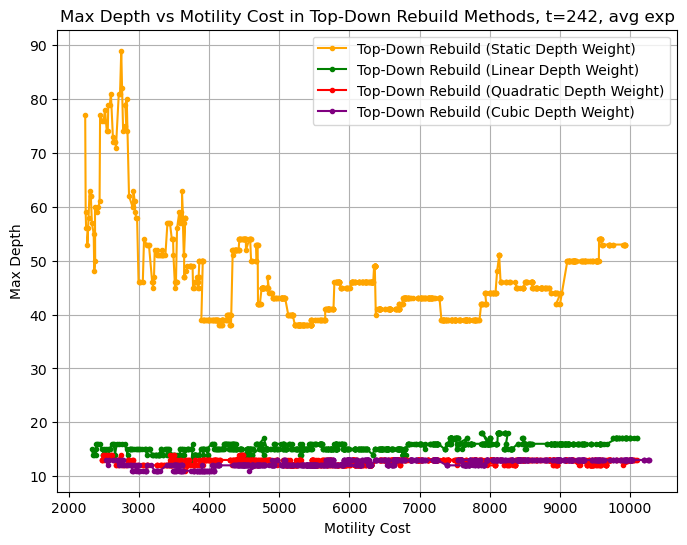

In [29]:
static_rebuild_max_depths = [cost[4] for cost in pareto_list_top_down_rebuild]
linear_rebuild_max_depths = [cost[4] for cost in pareto_list_top_down_rebuild_linear_depth_weight]
quadratic_rebuild_max_depths = [cost[4] for cost in pareto_list_top_down_rebuild_quadratic_depth_weight]
cubic_rebuild_max_depths = [cost[4] for cost in pareto_list_top_down_rebuild_cubic_depth_weight]
plt.figure(figsize=(8, 6))
plt.plot(pareto_xyz_cost_list_top_down_rebuild, static_rebuild_max_depths, color='orange', marker='o', linestyle='-',  markersize=3, label='Top-Down Rebuild (Static Depth Weight)')
plt.plot(pareto_xyz_cost_list_top_down_rebuild_linear_depth_weight, linear_rebuild_max_depths, color='green', marker='o', linestyle='-', markersize=3, label='Top-Down Rebuild (Linear Depth Weight)')
plt.plot(pareto_xyz_cost_list_top_down_rebuild_quadratic_depth_weight, quadratic_rebuild_max_depths, color='red', marker='o', linestyle='-', markersize=3, label='Top-Down Rebuild (Quadratic Depth Weight)')
plt.plot(pareto_xyz_cost_list_top_down_rebuild_cubic_depth_weight, cubic_rebuild_max_depths, color='purple', marker='o', linestyle='-', markersize=3, label='Top-Down Rebuild (Cubic Depth Weight)')
plt.xlabel('Motility Cost')
plt.ylabel('Max Depth')
plt.title(f'Max Depth vs Motility Cost in Top-Down Rebuild Methods, t=242, avg exp')
plt.grid(True)
plt.legend()
plt.show()

In [22]:
np.min(linear_rebuild_max_depths)

np.int64(13)

In [ ]:
pareto_list_paired_bottom_up_rebuild = opt.paired_bottom_up_rebuild_runner()

In [ ]:
pareto_list_top_down_balanced_rebuild = opt.top_down_balanced_rebuild_runner()

In [65]:
pareto_list_direct_bottom_up_rebuild = opt.direct_bottom_up_rebuild_runner()

Computing pareto costs:   0%|          | 0/1001 [00:00<?, ?it/s]

In [15]:
results_df = pd.read_csv('output/internal_opt/s3_242_3d_l2/pareto_front.csv')
pareto_xyz_cost_list_by_layer = results_df["Bottom-up By Layer XYZ Cost"].tolist()
pareto_exp_cost_list_by_layer = results_df["Bottom-up By Layer Exp Cost"].tolist()
pareto_xyz_cost_list_top_down_rebuild = results_df["Top-Down Rebuild XYZ Cost"].tolist()
pareto_exp_cost_list_top_down_rebuild = results_df["Top-Down Rebuild Exp Cost"].tolist()
pareto_xyz_cost_list_top_down_balanced_rebuild = results_df["Top-Down Balanced Rebuild XYZ Cost"].tolist()
pareto_exp_cost_list_top_down_balanced_rebuild = results_df["Top-Down Balanced Rebuild Exp Cost"].tolist()
pareto_xyz_cost_list_paired_bottom_up_rebuild = results_df["Paired Bottom-Up Rebuild XYZ Cost"].tolist()
pareto_exp_cost_list_paired_bottom_up_rebuild = results_df["Paired Bottom-Up Rebuild Exp Cost"].tolist()    
# pareto_xyz_cost_list_mst = [xyz_cost for xyz_cost, _, _ in pareto_mst_list]
# pareto_exp_cost_list_mst = [exp_cost for _, exp_cost, _ in pareto_mst_list]
# pareto_xyz_cost_list_direct_bottom_up_rebuild = [xyz_cost for xyz_cost, _, _, _, _ in pareto_list_direct_bottom_up_rebuild]
# pareto_exp_cost_list_direct_bottom_up_rebuild = [exp_cost for _, exp_cost, _, _, _ in pareto_list_direct_bottom_up_rebuild]

In [60]:
mst_depth = [max_depth for _, _, max_depth in pareto_mst_list]
np.mean(mst_depth), np.min(mst_depth), np.max(mst_depth)

(np.float64(37.21078921078921), np.int64(28), np.int64(58))

In [ ]:
alpha_tree_tops_list = []
for i in range(1001):
    alpha = 0 + 0.001 * i
    alpha_tree_tops_list.append((alpha, pareto_list_direct_bottom_up_rebuild[i][4]))
# plot alpha vs tree tops
alphas = [x[0] for x in alpha_tree_tops_list]
tree_tops = [x[1] for x in alpha_tree_tops_list]
plt.figure(figsize=(6,4))
plt.plot(alphas, tree_tops, marker='o', markersize=2)
plt.xlabel('Alpha (weight for XYZ cost)')
plt.ylabel('Number of tree tops after direct bottom-up rebuild')
plt.title('Alpha vs Number of Tree Tops')
plt.grid(True)

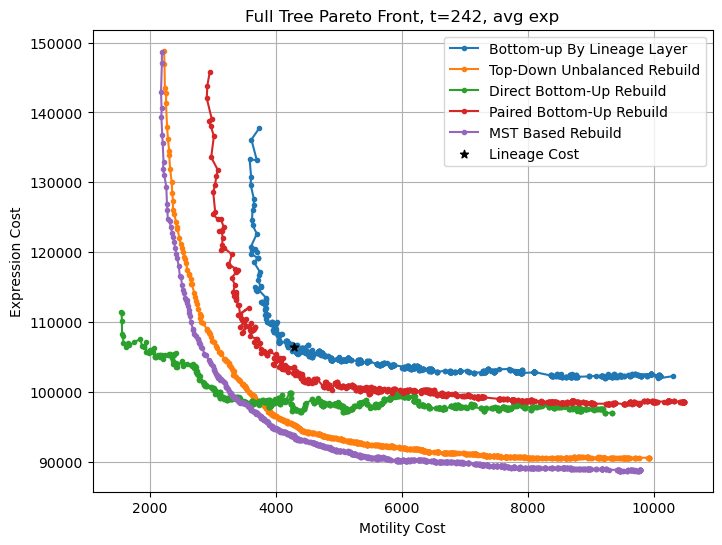

In [67]:
plt.figure(figsize=(8, 6))
plt.plot(pareto_xyz_cost_list_by_layer, pareto_exp_cost_list_by_layer, marker='o', linestyle='-',  markersize=3, label='Bottom-up By Lineage Layer')
plt.plot(pareto_xyz_cost_list_top_down_rebuild, pareto_exp_cost_list_top_down_rebuild, marker='o', linestyle='-',  markersize=3, label='Top-Down Unbalanced Rebuild')
plt.plot(pareto_xyz_cost_list_direct_bottom_up_rebuild, pareto_exp_cost_list_direct_bottom_up_rebuild, marker='o', linestyle='-', markersize=3, label='Direct Bottom-Up Rebuild')
plt.plot(pareto_xyz_cost_list_paired_bottom_up_rebuild, pareto_exp_cost_list_paired_bottom_up_rebuild, marker='o', linestyle='-', markersize=3, label='Paired Bottom-Up Rebuild')
plt.plot(pareto_xyz_cost_list_mst, pareto_exp_cost_list_mst, marker='o', linestyle='-', markersize=3, label='MST Based Rebuild')
plt.xlabel('Motility Cost')
plt.ylabel('Expression Cost')
plt.scatter(opt.lineage_xyz_cost, opt.lineage_exp_cost, color='black', marker='*', label='Lineage Cost', zorder=99)
plt.title(f'Full Tree Pareto Front, t=242, avg exp')
plt.grid(True)
plt.legend()
plt.show()

In [68]:
results_df = pd.DataFrame({
    'Bottom-up By Layer XYZ Cost': pareto_xyz_cost_list_by_layer,
    'Bottom-up By Layer Exp Cost': pareto_exp_cost_list_by_layer,
    'Top-Down Rebuild XYZ Cost': pareto_xyz_cost_list_top_down_rebuild,
    'Top-Down Rebuild Exp Cost': pareto_exp_cost_list_top_down_rebuild,
    'Top-Down Balanced Rebuild XYZ Cost': pareto_xyz_cost_list_top_down_balanced_rebuild,
    'Top-Down Balanced Rebuild Exp Cost': pareto_exp_cost_list_top_down_balanced_rebuild,
    'Paired Bottom-Up Rebuild XYZ Cost': pareto_xyz_cost_list_paired_bottom_up_rebuild,
    'Paired Bottom-Up Rebuild Exp Cost': pareto_exp_cost_list_paired_bottom_up_rebuild,
    'MST Based Rebuild XYZ Cost': pareto_xyz_cost_list_mst,
    'MST Based Rebuild Exp Cost': pareto_exp_cost_list_mst,
    'Direct Bottom-Up Rebuild XYZ Cost': pareto_xyz_cost_list_direct_bottom_up_rebuild,
    'Direct Bottom-Up Rebuild Exp Cost': pareto_exp_cost_list_direct_bottom_up_rebuild,
})

In [69]:
# save results to csv
results_df.to_csv('output/internal_opt/s3_242_3d_l2/pareto_front.csv', index=False)

In [ ]:
pareto_list_direct_bottom_up_rebuild = opt.direct_bottom_up_rebuild_runner()

In [ ]:
pareto_list_terminal_only = opt.terminal_only_rebuild_runner()

In [ ]:
pareto_list_paired_bottom_up_rebuild = opt.paired_bottom_up_rebuild_runner()

In [ ]:
# all tree bottom up by layer pareto optimization
pareto_list_by_layer = opt.bottom_up_by_layer_runner()
pareto_list_by_cell = opt.bottom_up_by_cell_runner()


In [ ]:
pareto_xyz_cost_list_by_layer = [cost[0] for cost in pareto_list_by_layer]
pareto_exp_cost_list_by_layer = [cost[1] for cost in pareto_list_by_layer]
pareto_xyz_cost_list_by_cell = [cost[0] for cost in pareto_list_by_cell]
pareto_exp_cost_list_by_cell = [cost[1] for cost in pareto_list_by_cell]
plt.figure(figsize=(8, 6))
plt.plot(pareto_xyz_cost_list_by_layer, pareto_exp_cost_list_by_layer, marker='o', linestyle='-', color='blue', markersize=3, label='Pareto Front (By Layer)')
plt.plot(pareto_xyz_cost_list_by_cell, pareto_exp_cost_list_by_cell, marker='o', linestyle='-', color='green', markersize=3, label='Pareto Front (By Cell)')
plt.xlabel('Motility Cost')
plt.ylabel('Expression Cost')
plt.scatter(opt.lineage_xyz_cost, opt.lineage_exp_cost, color='red', label='Lineage Cost')
plt.title(f'Full tree bottom up, t=248, avg exp')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
first_layer_names = ['ABa', 'ABp', 'P2', 'EMS']
pareto_list_by_layer_subtree = []
pareto_list_by_cell_subtree = []
lineage_cost_subtree = []
for name, layer in zip(first_layer_names, first_layer):
    subtree_pareto_list_by_layer = opt.bottom_up_by_layer_runner(first_internal_layer=[layer])
    subtree_pareto_list_by_cell = opt.bottom_up_by_cell_runner(first_internal_layer=[layer])
    pareto_list_by_layer_subtree.append(subtree_pareto_list_by_layer)
    pareto_list_by_cell_subtree.append(subtree_pareto_list_by_cell)
    lineage_cost_subtree.append(opt.calc_lineage_cost(first_internal_tree_ids=[layer[0]]))

In [ ]:
subtree_edge_counts = [360, 368, 184, 96]

In [ ]:
for edge_count, name, subtree_pareto_list_by_layer, subtree_pareto_list_by_cell, lineage_cost in \
        zip(subtree_edge_counts, first_layer_names, pareto_list_by_layer_subtree, pareto_list_by_cell_subtree, lineage_cost_subtree):
    pareto_xyz_cost_list_by_layer = [cost[0] for cost in subtree_pareto_list_by_layer]
    pareto_exp_cost_list_by_layer = [cost[1] for cost in subtree_pareto_list_by_layer]
    pareto_xyz_cost_list_by_cell = [cost[0] for cost in subtree_pareto_list_by_cell]
    pareto_exp_cost_list_by_cell = [cost[1] for cost in subtree_pareto_list_by_cell]
    plt.figure(figsize=(8, 6))
    plt.plot(pareto_xyz_cost_list_by_layer, pareto_exp_cost_list_by_layer, marker='o', linestyle='-', color='blue', markersize=3, label='Pareto Front (By Layer)')
    plt.plot(pareto_xyz_cost_list_by_cell, pareto_exp_cost_list_by_cell, marker='o', linestyle='-', color='green', markersize=3, label='Pareto Front (By Cell)')
    plt.xlabel('Motility Cost')
    plt.ylabel('Expression Cost')
    plt.scatter(lineage_cost[0], lineage_cost[1], color='red', label='Lineage Cost')
    plt.title(f'Subtree {name} bottom up, t=248, avg exp, edges={edge_count}')
    plt.grid(True)
    plt.legend()
    plt.show()

In [ ]:
pareto_list_by_layer_subtree_sum = np.array(pareto_list_by_layer_subtree).sum(axis=0)
pareto_list_by_cell_subtree_sum = np.array(pareto_list_by_cell_subtree).sum(axis=0)

pareto_xyz_cost_list_by_layer_subtree_aggregate = [cost[0] for cost in pareto_list_by_layer_subtree_sum]
pareto_exp_cost_list_by_layer_subtree_aggregate = [cost[1] for cost in pareto_list_by_layer_subtree_sum]
pareto_xyz_cost_list_by_cell_subtree_aggregate = [cost[0] for cost in pareto_list_by_cell_subtree_sum]
pareto_exp_cost_list_by_cell_subtree_aggregate = [cost[1] for cost in pareto_list_by_cell_subtree_sum]
pareto_xyz_cost_list_by_layer = [cost[0] for cost in pareto_list_by_layer]
pareto_exp_cost_list_by_layer = [cost[1] for cost in pareto_list_by_layer]
pareto_xyz_cost_list_by_cell = [cost[0] for cost in pareto_list_by_cell]
pareto_exp_cost_list_by_cell = [cost[1] for cost in pareto_list_by_cell]
plt.figure(figsize=(8, 6))
plt.plot(pareto_xyz_cost_list_by_layer, pareto_exp_cost_list_by_layer, marker='o', linestyle='-', color='blue', markersize=3, label='Pareto Front (By Layer)')
plt.plot(pareto_xyz_cost_list_by_cell, pareto_exp_cost_list_by_cell, marker='o', linestyle='-', color='green', markersize=3, label='Pareto Front (By Cell)')
plt.plot(pareto_xyz_cost_list_by_layer_subtree_aggregate, pareto_exp_cost_list_by_layer_subtree_aggregate, marker='o', linestyle='-', color='darkblue', markersize=3, label='Subtree combine by layer)')
plt.plot(pareto_xyz_cost_list_by_cell_subtree_aggregate, pareto_exp_cost_list_by_cell_subtree_aggregate, marker='o', linestyle='-', color='darkgreen', markersize=3, label='Subtree combine by cell)')
plt.xlabel('Motility Cost')
plt.ylabel('Expression Cost')
plt.scatter(opt.lineage_xyz_cost, opt.lineage_exp_cost, color='red', label='Lineage Cost', zorder=5)
plt.title(f'Bottom up full tree vs subtree combine, t=248, avg exp')
plt.grid(True)
plt.legend()
plt.show()


In [ ]:
pareto_list_by_layer